In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, TimeDistributed
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


In [5]:
np.random.seed(7)
tf.random.set_seed(7)

In [6]:
#CARGAR LOS DATOS
data_train = pd.read_csv('train.csv', parse_dates=['date'])
data_test = pd.read_csv('test.csv', parse_dates=['date'])

#FILTRAR UNA SERIE
train= data_train.query("store==1 & item==1").copy()
train= train.sort_values('date')
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [7]:
print(len(train))

1826


In [8]:
def make_supervised_windows(series: np.ndarray, window: int, lag: int):
    X, y = [], []
    for i in range(window, len(series) - lag):
        X.append(series[i-window: i+1])
        y.append(series[i + lag])
    return np.array(X), np.array(y)

window = 29
lag = 1

X, y= make_supervised_windows(train['sales'].values, window, lag)
print("X", X.shape, "y", y.shape)

X (1796, 30) y (1796,)


In [9]:
# DIVISION TEMPORAL Y ESCALADO 
cut= int(len(X)* 0.8)
X_train, X_test= X[:cut], X[cut:]
y_train, y_test= y[:cut], y[cut:]

scaler_x= StandardScaler().fit(X_train)
scaler_y= StandardScaler().fit(y_train.reshape(-1, 1))

X_train_s = scaler_x.transform(X_train)
X_test_s = scaler_x.transform(X_test)
y_train_s = scaler_y.transform(y_train.reshape(-1, 1)).ravel()
y_test_s = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print("X_train_s", X_train_s.shape, "y_train_s", y_train_s.shape)

X_train_3d = X_train_s.reshape((len(X_train_s), window+1, 1))
X_test_3d = X_test_s.reshape((len(X_test_s), window+1, 1))

print("Train 3d:", X_train_3d.shape, "Test 3d:", X_test_3d.shape)

X_train_s (1436, 30) y_train_s (1436,)
Train 3d: (1436, 30, 1) Test 3d: (360, 30, 1)


In [10]:
# CNN 1D 
model_cnn= Sequential(
    [Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(window+1, 1)),
     MaxPooling1D(pool_size=2),
     Flatten(),
     Dense(32, activation='relu'),
     Dense(1)
    ]
)
model_cnn.compile(optimizer='adam', loss='mse')
model_cnn.summary()

c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        14,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,529 (56.75 KB)

 Trainable params: 14,529 (56.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_cnn= model_cnn.fit(X_train_3d, y_train_s, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.6623
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5614
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5421
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5235
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5066
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4952
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4815
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4706
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4581
Epoch 10/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4458
Epoch 11/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4373
Epoch 12/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4251
Epoch 13/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4126
Epoch 14/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3988
Epoch 15/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3874
Epoc

In [12]:
# PREDICTIONS 
pred_cnn_s= model_cnn.predict(X_test_3d).ravel()
pred_cnn= scaler_y.inverse_transform(pred_cnn_s.reshape(-1, 1)).ravel()
print("RSME:", np.sqrt(mean_squared_error(y_test, pred_cnn)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
RSME: 7.956671203347766


In [13]:
# LSTM 
model_lstm= Sequential(
    [LSTM(50, activation='tanh', input_shape=(window+1, 1)),
     Dense(1)
    ]
)
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_lstm= model_lstm.fit(X_train_3d, y_train_s, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.7500
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.6699
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.6672
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6654
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6638
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6623
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6608
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6590
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.6568
Epoch 10/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6538
Epoch 11/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.6497
Epoch 12/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6439
Epoch 13/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6389
Epoch 14/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.6363
Epoch 15/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - lo

In [15]:
pred_lstm_s= model_lstm.predict(X_test_3d).ravel()
pred_lstm= scaler_y.inverse_transform(pred_lstm_s.reshape(-1, 1)).ravel()
print("RSME:", np.sqrt(mean_squared_error(y_test, pred_lstm)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
RSME: 5.257225151187954


In [16]:
# CNN + LSTM
subseq = 5
assert(window + 1) % subseq == 0, "window must be divisible by subseq"
step_per_subseq = (window+ 1) // subseq

Xtr4 = X_train_3d.reshape((len(X_train_3d), subseq, step_per_subseq, 1))
Xva4 = X_test_3d.reshape((len(X_test_3d), subseq, step_per_subseq, 1))

model_cnn_lstm = Sequential([
    TimeDistributed(Conv1D(filters=32, kernel_size=3, activation="relu"), 
                    input_shape=(subseq, step_per_subseq, 1)),
    TimeDistributed(MaxPooling1D(2)),
    TimeDistributed(Flatten()),  
    LSTM(32, activation="tanh"),
    Dense(1)
])

model_cnn_lstm.compile(optimizer="adam", loss="mse")
model_cnn_lstm.summary()

c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 4, 32)       │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 2, 32)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 64)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,577 (49.13 KB)

 Trainable params: 12,577 (49.13 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_cnn_lstm= model_cnn_lstm.fit(Xtr4, y_train_s, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.7391
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6535
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.6295
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6153
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6052
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5965
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5886
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5816
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5752
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5693
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5639
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5590
Epoch 13/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5546
Epoch 14/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5506
Epoch 15/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5468
Epoc

In [18]:
# Xva4 are the test samples
pred_cnn_lstm_s= model_cnn_lstm.predict(Xva4).ravel()
pred_cnn_lstm= scaler_y.inverse_transform(pred_cnn_lstm_s.reshape(-1, 1)).ravel()
print("RSME:", np.sqrt(mean_squared_error(y_test, pred_cnn_lstm)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step
RSME: 5.294711501031042


In [19]:
# PLOTTING RESULTS 
rsme_cnn = np.sqrt(mean_squared_error(y_test, pred_cnn))
rsme_lstm = np.sqrt(mean_squared_error(y_test, pred_lstm))
rsme_cnn_lstm = np.sqrt(mean_squared_error(y_test, pred_cnn_lstm))

print("---------Results---------")
print("RSME CNN:", rsme_cnn)
print("RSME LSTM:", rsme_lstm)
print("RSME CNN+LSTM:", rsme_cnn_lstm)


---------Results---------
RSME CNN: 7.956671203347766
RSME LSTM: 5.257225151187954
RSME CNN+LSTM: 5.294711501031042


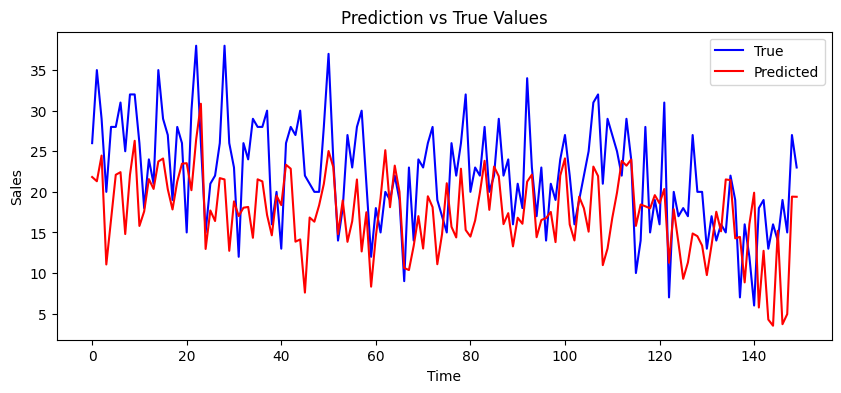

In [20]:
y_true = y_test
y_pred = pred_cnn

k=150 if len(y_true) > 150 else len(y_true)

plt.figure(figsize=(10, 4))
plt.plot(y_true[-k:], label='True', color='blue')
plt.plot(y_pred[-k:], label='Predicted', color='red')
plt.title(f'Prediction vs True Values')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()

